In [1]:
%matplotlib inline

import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker
from matplotlib import rc, rcParams
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pickle as pkl

# Make use of TeX\ufeff
rc('text',usetex=True)
# Change all fonts to 'Computer Modern'
rc('font',**{'size':14, 'family':'serif','serif':['Times New Roman']})
rc('xtick.major', size=5, pad=7)
rc('xtick', labelsize=15)
rc('ytick.major', size=5, pad=7)
rc('ytick', labelsize=15)

# uses matplotlib-label-lines, see for example https://github.com/cphyc/matplotlib-label-lines
from labellines import labelLine, labelLines

# this needs to point to the folder where darkelf.py is stored
work_dir = os.getcwd()
sys.path.append(work_dir+"/..")
plotdir=work_dir+"/plots/"

from darkelf import darkelf, targets

In [2]:
def get_limit(target,mX,threshold=-1.0,method="grid",mediator="massless",kcut=0.0,exposure=1):
    
    target.update_params(mX=mX,mediator=mediator)
    R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut,vdist=target.vdist)
    if R==0.0:
        return 1.0
    else:
        return 3.0*1.0e-38/(R*exposure) # exposure in kg-year (default 1)

# Plot v dists - Dark Proton - SENSEI and Xenon Limits (28/4/26)

In [31]:
masslist=np.logspace(6,15,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

sqrtmrat = 1e0

expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

targetlabels=["Si - halo, CDM","Si - disk, aDM","Si - halo, aDM","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","Si - disk, little both"]

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":1},
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms":0.1,"vekms": 233,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":0.1,"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 ),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":0.01}] # all must be positive

target_list = [darkelf(target='Si',mX=mX,filename="Si_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],fD=v["fD"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

# flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
# flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

# etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
# etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, https://onlinelibrary.wiley.com/doi/pdf/10.

In [32]:
# convert cm^2 ref cross-section to \kappa
# see eg (2.2) of 1509.01598

alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def sigmae_to_kappa_exact(sigmae_cm2, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = np.asarray(sigmae_cm2, dtype=float) / cm2_per_GeVminus2
    return (alpha * m_e_GeV**2 / (4*np.sqrt(np.pi)*mu)) * np.sqrt(sigmae_GeVminus2)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = (
        (4*np.sqrt(np.pi)*mu*kappa)/(alpha*m_e_GeV**2)
    )**2
    return sigmae_GeVminus2 * cm2_per_GeVminus2

### electron recoil

In [5]:
task = ("write","read")[1]

# test_read = np.array([])

fname = "lim_massless_SENSEI_exp_pD_11_5_26"

if task == "write":

    lim_massless=[]

    expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

    # lim_massive=[]
    for target in target_list:
        print(target.target)
        # for v in vs_list:
        #     print(v)
        if target.target=="Al":
            # for Al, take 5 eV threshold
            lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
        else:
            # for the others, take the default threshold (2e- or 2 x bandgap)
            lim_massless.append([get_limit(target,mX,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

    lim_massless_DD=np.array(lim_massless) 

    with open(fname, "wb") as f:
        pkl.dump(lim_massless,f)

elif task == "read":
    with open(fname, "rb") as f:
        lim_massless = pkl.load(f)


lim_kappa = [sigmae_to_kappa_exact(lim_massless[i], masslist) for i in range(len(lim_massless))]

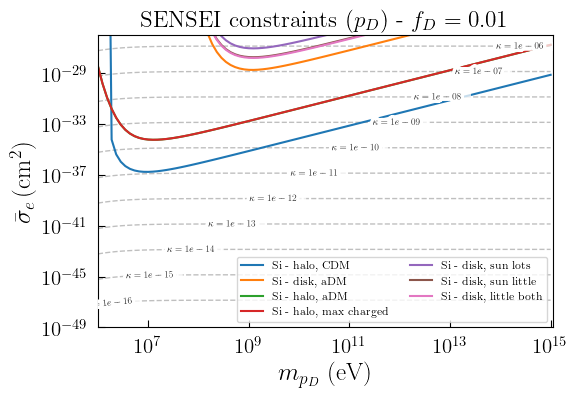

In [6]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0, 1.0, 10))

for i in range(len(lim_massless)):
    axs.plot(
        masslist,
        lim_massless[i],
        label=targetlabels[i],
        color=colors[i]
    )

axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e6, 1.1e15])
axs.set_ylim([1e-49, 1.1e-26])
axs.set_xlabel("$m_{p_D}$ (eV)", fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$", fontsize=18)
axs.tick_params(direction="in", which="both")

axs.set_title(r"SENSEI constraints ($p_D$) - $f_D = 0.01$")


# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)


# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless)]
main_labels = labels[:len(lim_massless)]

axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="lower right"
)

fig.tight_layout()
fig.subplots_adjust(wspace=0.3)

### Now Nuclear

In [46]:
from millicharge_nr import attach_mc_nr_methods
attach_mc_nr_methods(darkelf)

def get_limit_nuclear(
    target,
    mX,
    material="Xe",
    mediator="massless",
    exposure=1,
    q_dm=1.0,
    kappa_ref=1e-9,
    ER_min_eV=None,
    ER_max_eV=None,
):
    target.update_params(mX=mX, mediator=mediator)

    R = target.R_mc(
        material=material,
        kappa=kappa_ref,
        q_dm=q_dm,
        vdist=target.vdist,
        ER_min_eV=ER_min_eV,
        ER_max_eV=ER_max_eV,
    )

    # if R == 0.0:
    #     return 1.0
    if (not np.isfinite(R)) or R <= 0.0:
        return np.inf
    else:
        return kappa_ref * np.sqrt(3.0 / (R * exposure))

In [47]:
lim_massless_nuc=[]

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target in target_list:
    print(target.target)
    lim_massless_nuc.append([
        get_limit_nuclear(
            target,
            mX,
            material="Xe",
            mediator="massless",
            exposure=expXENON1T,
            q_dm=1.0,
            ER_min_eV = 4.9e3,
            ER_max_eV = 40.9e3 # 1805.12562
        )
        for mX in masslist
    ])

lim_massless_nuc_DD = np.array(lim_massless_nuc)

lim_sigmae = [
    kappa_to_sigmae_exact(lim_massless_nuc[i], masslist)
    for i in range(len(lim_massless_nuc))
]

Si
Si
Si
Si
Si
Si
Si


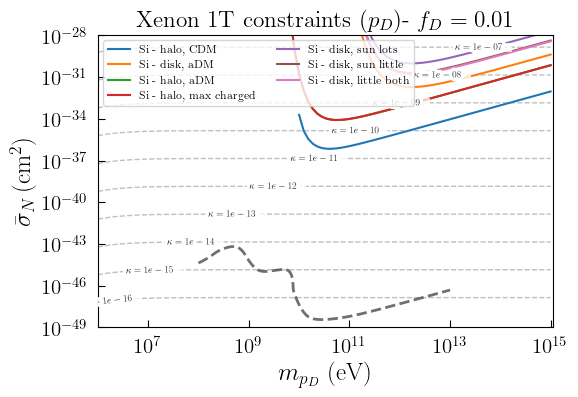

In [48]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_sigmae)):
    axs.plot(masslist,lim_sigmae[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e6,1.1e15])
axs.set_ylim([1e-49,1.1e-28])
axs.set_xlabel("$m_{p_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_N\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints ($p_D$)- $f_D = 0.01$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Neutrino fog / floor (2109.03116)
# ------------------------------------------------------------------
 
floor_file = "Xe_SI.txt"

m_floor_GeV, sigma_floor_cm2 = np.loadtxt(floor_file, unpack=True)

# If your x-axis is m_chi in eV:
m_floor_eV = m_floor_GeV * 1e9

# --- add to existing axes ---
axs.plot(
    m_floor_eV,
    sigma_floor_cm2,
    ls="--",
    lw=2.0,
    color="0.2",
    alpha=0.7,
    label=r"Xe SI $\nu$ floor"
)


# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless_nuc)]
main_labels = labels[:len(lim_massless_nuc)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="upper left"
)



fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
# labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
        #    ha='center',va='center',align=True,bbox=props)

move the damn legend

### debug plots

In [45]:
mX = 50e9  # eV
kappa_ref = 1e-9
ER_min_eV = 4.9e3
ER_max_eV = 40.9e3

target = target_list[0]
target.update_params(mX=mX, mediator="massless")

print("target:", target.target)
print("vdist:", target.vdist)
print("mX:", target.mX)
print("rhoX:", target.rhoX)
print("eVtokg:", target.eVtokg)
print("c0:", getattr(target, "c0", None))
print("c0cms:", getattr(target, "c0cms", None))

R = target.R_mc(
    material="Xe",
    kappa=kappa_ref,
    q_dm=1.0,
    vdist="halo",
    ER_min_eV=ER_min_eV,
    ER_max_eV=ER_max_eV,
)
print("R_mc:", R)
print("events in 1 ty:", R * 1000.0)
print("kappa limit:", kappa_ref * np.sqrt(3/(R*1000.0)) if R > 0 else np.nan)

target: Si
vdist: halo
mX: 50000000000.0
rhoX: 400000000.0
eVtokg: 1.78e-36
c0: 299792.458
c0cms: 29979245800.0
R_mc: 5.848585775385815
events in 1 ty: 5848.585775385815
kappa limit: 2.2648278434075245e-11


In [ ]:
for ER in [4.9e3, 1e4, 2e4, 4e4]:
    print("ER =", ER)
    print("vmin =", vmin_nr(ER, NR_MATERIALS["Xe"].isotopes[3].mass_eV, target.mX))
    print("eta =", target.etav(target.vmin_nr(ER, NR_MATERIALS["Xe"].isotopes[3].mass_eV, target.mX)))
    print("dRdER =", target.dRdER_mc(ER, material="Xe", kappa=1e-9, q_dm=1.0, vdist="halo"))

ER = 4900.0


AttributeError: 'darkelf' object has no attribute 'vmin_nr'

In [44]:
print(masslist[:10], masslist[-10:])
print(lim_massless_nuc_DD[0][:10], lim_massless_nuc_DD[0][-10:])
print(lim_sigmae[0][:10], lim_sigmae[0][-10:])

[1000000.         1232846.73944207 1519911.08295293 1873817.42286038
 2310129.70008316 2848035.8684358  3511191.73421513 4328761.28108306
 5336699.23120631 6579332.24657568] [1.51991108e+14 1.87381742e+14 2.31012970e+14 2.84803587e+14
 3.51119173e+14 4.32876128e+14 5.33669923e+14 6.57933225e+14
 8.11130831e+14 1.00000000e+15]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] [9.99442486e-10 1.10971028e-09 1.23214530e-09 1.36808999e-09
 1.51903488e-09 1.68663499e-09 1.87272793e-09 2.07935409e-09
 2.30877899e-09 2.56351813e-09]
[6.16514622e-16 7.03515684e-16 7.88363846e-16 8.68993168e-16
 9.43840590e-16 1.01189070e-15 1.07264370e-15 1.12603343e-15
 1.17232294e-15 1.21199910e-15] [1.40600646e-33 1.73336857e-33 2.13695589e-33 2.63451719e-33
 3.24793403e-33 4.00418297e-33 4.93652202e-33 6.08595318e-33
 7.50302563e-33 9.25005879e-33]


### Wimp comparison

In [10]:
from millicharge_nr import attach_wimp_SI_nr_methods
attach_wimp_SI_nr_methods(darkelf)

In [11]:
lim_wimp_SI_nuc = []

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target, vinfo in zip(target_list, vs_list):
    print(target.target, vinfo["vdist"])

    lim_wimp_SI_nuc.append([
        target.sigma_n_limit_wimp_SI(
            material="Xe",
            exposure_kgyr=expXENON1T,
            n_limit=2.3,
            fp_over_fn=1.0,          # standard isospin-conserving SI WIMP
            vdist=vinfo["vdist"],    # use same halo/disk choice as the target
            ER_min_eV=4.9e3,
            ER_max_eV=40.9e3,        # XENON1T 1805.12562 NR ROI
            npts=800,
            sigma_ref_cm2=1e-45,
        )
        for mX in masslist
        for _ in [setattr(target, "mX", mX)]
    ])

lim_wimp_SI_nuc_DD = np.array(lim_wimp_SI_nuc)

Si halo
Si disk
Si disk
Si disk
Si disk
Si disk
Si disk


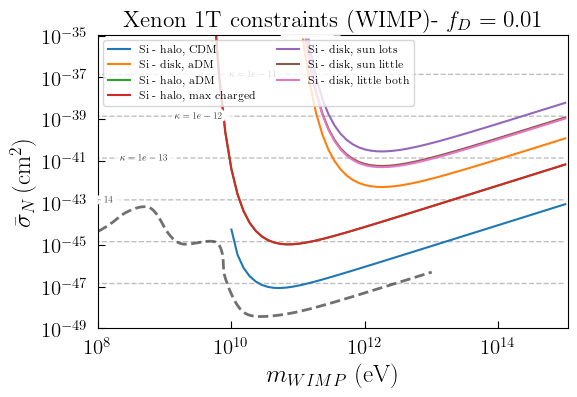

In [13]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_wimp_SI_nuc_DD)):
    axs.plot(masslist,lim_wimp_SI_nuc_DD[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e8,1.1e15])
axs.set_ylim([1e-49,1.1e-35])
axs.set_xlabel("$m_{WIMP}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_N\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints (WIMP)- $f_D = 0.01$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Neutrino fog / floor (2109.03116)
# ------------------------------------------------------------------
 
floor_file = "Xe_SI.txt"

m_floor_GeV, sigma_floor_cm2 = np.loadtxt(floor_file, unpack=True)

# If your x-axis is m_chi in eV:
m_floor_eV = m_floor_GeV * 1e9

# --- add to existing axes ---
axs.plot(
    m_floor_eV,
    sigma_floor_cm2,
    ls="--",
    lw=2.0,
    color="0.2",
    alpha=0.7,
    label=r"Xe SI $\nu$ floor"
)


# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_wimp_SI_nuc_DD)]
main_labels = labels[:len(lim_wimp_SI_nuc_DD)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="upper left"
)



fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
# labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
        #    ha='center',va='center',align=True,bbox=props)

The CDM line matches xenon wimp limits from eg fig 5 of 1805.12562

# Plot v dists - Dark Electron - SENSEI and Xenon Limits (22/4/26)

In [14]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later

sqrtmrat = 1e2

expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, aDM","Si - halo, aDM","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","Si - disk, little both"]

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":1},
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":0.01}] # all must be positive

target_list = [darkelf(target='Si',mX=mX,filename="Si_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],fD=v["fD"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, https://onlinelibrary.wiley.com/doi/pdf/10.

In [15]:
# convert cm^2 ref cross-section to \kappa
# see eg (2.2) of 1509.01598

alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def sigmae_to_kappa_exact(sigmae_cm2, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = np.asarray(sigmae_cm2, dtype=float) / cm2_per_GeVminus2
    return (alpha * m_e_GeV**2 / (4*np.sqrt(np.pi)*mu)) * np.sqrt(sigmae_GeVminus2)

### electron recoil

In [16]:
task = ("write","read")[1]

# test_read = np.array([])

# fname = "lim_massless_SENSEI_exp_22_4_22"
fname = "lim_massless_SENSEI_exp_11_5_26"

if task == "write":
    lim_massless=[]

    expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

    # lim_massive=[]
    for target in target_list:
        print(target.target)
        # for v in vs_list:
        #     print(v)
        if target.target=="Al":
            # for Al, take 5 eV threshold
            lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
        else:
            # for the others, take the default threshold (2e- or 2 x bandgap)
            lim_massless.append([get_limit(target,mX,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

    lim_massless_DD=np.array(lim_massless) 

    with open(fname, "wb") as f:
        pkl.dump(lim_massless,f)

elif task == "read":
    with open(fname, "rb") as f:
        lim_massless = pkl.load(f)

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 5 in `xvals` is outside the range of its associated line (xmin=np.float64(999.999999999999), xmax=np.float64(10000000000.0), xval=24494897427.831787). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 6 in `xvals` is outside the range of its associated line (xmin=np.float64(999.999999999999), xmax=np.float64(10000000000.0), xval=160947691199.96503). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 7 in `xvals` is outside the range of its associated line (xmin=np.float64(999.9999999

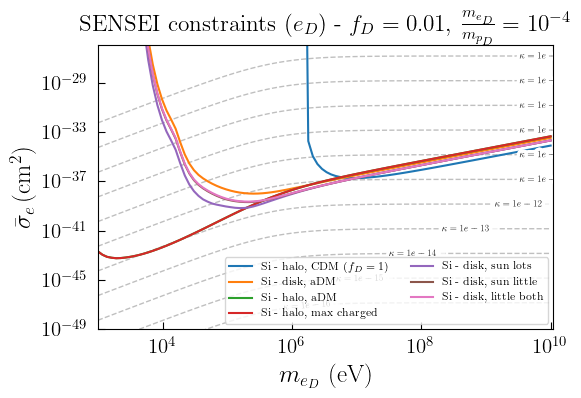

In [17]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-49,1.1e-26])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"SENSEI constraints ($e_D$) - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)




# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless_nuc)]
main_labels = labels[:len(lim_massless_nuc)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="lower right"
)



fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
# labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
        #    ha='center',va='center',align=True,bbox=props)

### Now Nuclear

In [18]:
from millicharge_nr import attach_mc_nr_methods
attach_mc_nr_methods(darkelf)

def get_limit_nuclear(
    target,
    mX,
    material="Xe",
    mediator="massless",
    exposure=1,
    q_dm=1.0,
    kappa_ref=1e-9,
    ER_min_eV=None,
    ER_max_eV=None,
):
    target.update_params(mX=mX, mediator=mediator)

    R = target.R_mc(
        material=material,
        kappa=kappa_ref,
        q_dm=q_dm,
        vdist=target.vdist,
        ER_min_eV=ER_min_eV,
        ER_max_eV=ER_max_eV,
    )

    if R == 0.0:
        return 1.0
    else:
        return kappa_ref * np.sqrt(3.0 / (R * exposure))

In [19]:
lim_massless=[]

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target in target_list:
    print(target.target)
    lim_massless.append([
        get_limit_nuclear(
            target,
            mX,
            material="Xe",
            mediator="massless",
            exposure=expXENON1T,
            q_dm=1.0,
        )
        for mX in masslist
    ])

lim_massless_DD = np.array(lim_massless)

Si
Si
Si
Si
Si
Si
Si


In [20]:
alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    """
    Inverse of sigmae_to_kappa_exact using the same convention:
        kappa = (alpha m_e^2 / (4 sqrt(pi) mu)) * sqrt(sigmae)

    Therefore:
        sigmae = [4 sqrt(pi) mu kappa / (alpha m_e^2)]^2

    Inputs
    ------
    kappa : float or array
        Millicharge / kinetic-mixing parameter in your convention.
    mchi_eV : float or array
        DM mass in eV.

    Returns
    -------
    sigmae_cm2 : float or array
        Reference electron cross section in cm^2
    """
    mu = mu_chie_GeV(mchi_eV)

    pref = (4*np.sqrt(np.pi) * mu * np.asarray(kappa, dtype=float)) / (alpha * m_e_GeV**2)

    sigmae_GeVminus2 = pref**2

    return sigmae_GeVminus2 * cm2_per_GeVminus2


# Example: convert your kappa-limit arrays back to sigmae arrays
lim_sigmae = [
    kappa_to_sigmae_exact(lim_massless[i], masslist)
    for i in range(len(lim_massless))
]

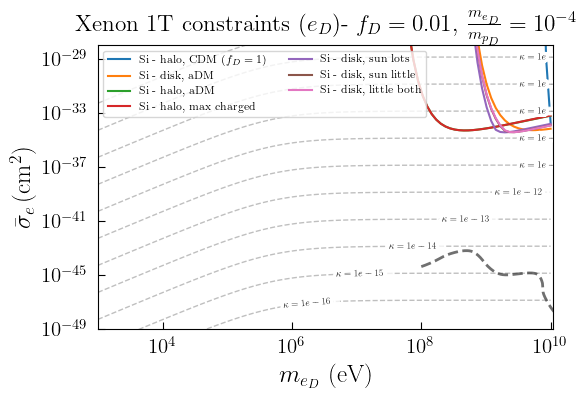

In [21]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_sigmae)):
    axs.plot(masslist,lim_sigmae[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-49,1.1e-28])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints ($e_D$)- $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Neutrino fog / floor (2109.03116)
# ------------------------------------------------------------------
 
floor_file = "Xe_SI.txt"

m_floor_GeV, sigma_floor_cm2 = np.loadtxt(floor_file, unpack=True)

# If your x-axis is m_chi in eV:
m_floor_eV = m_floor_GeV * 1e9

# --- add to existing axes ---
axs.plot(
    m_floor_eV,
    sigma_floor_cm2,
    ls="--",
    lw=2.0,
    color="0.2",
    alpha=0.7,
    label=r"Xe SI $\nu$ floor"
)


# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless_nuc)]
main_labels = labels[:len(lim_massless_nuc)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="upper left"
)


fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
#labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
#           ha='center',va='center',align=True,bbox=props)

compare to mtwh paper and nuclear recoil plots

# Plot v dists - Dark Electron (1e-2 mrat) - SENSEI and Xenon Limits (7/5/26)

In [22]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later

sqrtmrat = 1e1

expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, aDM","Si - halo, aDM","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","Si - disk, little both"]

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":0.01},
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":0.01}] # all must be positive

target_list = [darkelf(target='Si',mX=mX,filename="Si_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],fD=v["fD"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, https://onlinelibrary.wiley.com/doi/pdf/10.

In [24]:
# convert cm^2 ref cross-section to \kappa
# see eg (2.2) of 1509.01598

alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def sigmae_to_kappa_exact(sigmae_cm2, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = np.asarray(sigmae_cm2, dtype=float) / cm2_per_GeVminus2
    return (alpha * m_e_GeV**2 / (4*np.sqrt(np.pi)*mu)) * np.sqrt(sigmae_GeVminus2)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = (
        (4*np.sqrt(np.pi)*mu*kappa)/(alpha*m_e_GeV**2)
    )**2
    return sigmae_GeVminus2 * cm2_per_GeVminus2

### electron recoil

In [25]:
task = ("write","read")[1]

# test_read = np.array([])

# fname = "lim_massless_SENSEI_exp_sqrtmrat_1e1_7_5_26"
fname = "lim_massless_SENSEI_exp_sqrtmrat_1e1_11_5_26"

if task == "write":
    lim_massless=[]

    expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

    # lim_massive=[]
    for target in target_list:
        print(target.target)
        # for v in vs_list:
        #     print(v)
        if target.target=="Al":
            # for Al, take 5 eV threshold
            lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
        else:
            # for the others, take the default threshold (2e- or 2 x bandgap)
            lim_massless.append([get_limit(target,mX,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

    lim_massless_DD=np.array(lim_massless) 

    with open(fname, "wb") as f:
        pkl.dump(lim_massless,f)

elif task == "read":
    with open(fname, "rb") as f:
        lim_massless = pkl.load(f)

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 5 in `xvals` is outside the range of its associated line (xmin=np.float64(999.999999999999), xmax=np.float64(10000000000.0), xval=24494897427.831787). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 6 in `xvals` is outside the range of its associated line (xmin=np.float64(999.999999999999), xmax=np.float64(10000000000.0), xval=160947691199.96503). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 7 in `xvals` is outside the range of its associated line (xmin=np.float64(999.9999999

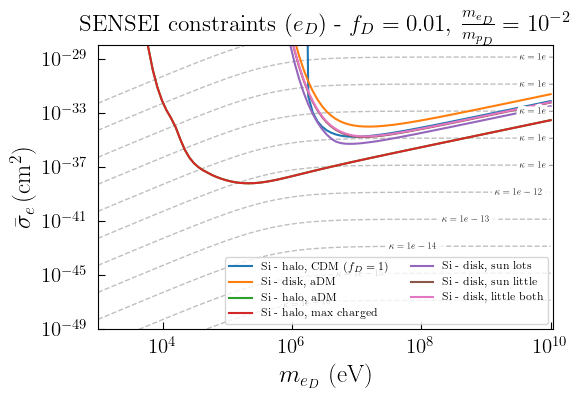

In [26]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-49,1.1e-28])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"SENSEI constraints ($e_D$) - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-2}$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)




# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless)]
main_labels = labels[:len(lim_massless)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="lower right"
)



fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
# labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
        #    ha='center',va='center',align=True,bbox=props)

### Now Nuclear

In [27]:
from millicharge_nr import attach_mc_nr_methods
attach_mc_nr_methods(darkelf)

def get_limit_nuclear(
    target,
    mX,
    material="Xe",
    mediator="massless",
    exposure=1,
    q_dm=1.0,
    kappa_ref=1e-9,
    ER_min_eV=None,
    ER_max_eV=None,
):
    target.update_params(mX=mX, mediator=mediator)

    R = target.R_mc(
        material=material,
        kappa=kappa_ref,
        q_dm=q_dm,
        vdist=target.vdist,
        ER_min_eV=ER_min_eV,
        ER_max_eV=ER_max_eV,
    )

    if R == 0.0:
        return 1.0
    else:
        return kappa_ref * np.sqrt(3.0 / (R * exposure))

In [28]:
lim_massless=[]

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target in target_list:
    print(target.target)
    lim_massless.append([
        get_limit_nuclear(
            target,
            mX,
            material="Xe",
            mediator="massless",
            exposure=expXENON1T,
            q_dm=1.0,
        )
        for mX in masslist
    ])

lim_massless_DD = np.array(lim_massless)

# Example: convert your kappa-limit arrays back to sigmae arrays
lim_sigmae = [
    kappa_to_sigmae_exact(lim_massless[i], masslist)
    for i in range(len(lim_massless))
]

Si
Si
Si
Si
Si
Si
Si


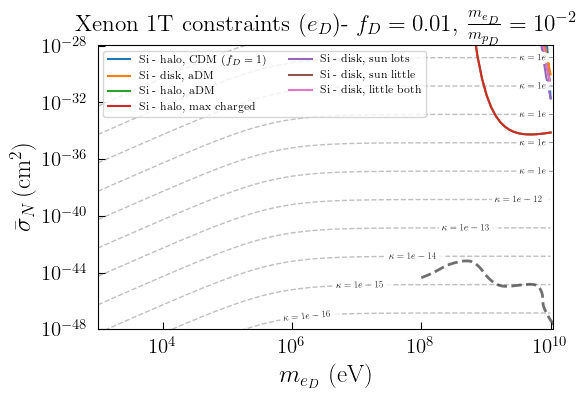

In [29]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_sigmae)):
    axs.plot(masslist,lim_sigmae[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-28])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_N\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints ($e_D$)- $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-2}$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Neutrino fog / floor (2109.03116)
# ------------------------------------------------------------------
 
floor_file = "Xe_SI.txt"

m_floor_GeV, sigma_floor_cm2 = np.loadtxt(floor_file, unpack=True)

# If your x-axis is m_chi in eV:
m_floor_eV = m_floor_GeV * 1e9

# --- add to existing axes ---
axs.plot(
    m_floor_eV,
    sigma_floor_cm2,
    ls="--",
    lw=2.0,
    color="0.2",
    alpha=0.7,
    label=r"Xe SI $\nu$ floor"
)


# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless)]
main_labels = labels[:len(lim_massless)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="upper left"
)


fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
#labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
#           ha='center',va='center',align=True,bbox=props)